In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
customer=pd.read_csv('customer_cleaned.csv')
product=pd.read_csv('product_cleaned.csv')
sales=pd.read_csv('sales_cleaned.csv')

In [3]:
df = (
    sales
    .merge(customer, on='Customer_ID', how='left')
    .merge(product, on='Product_ID', how='left')
)

print(df.shape)

(250000, 48)


In [5]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Product_ID', 'Quantity', 'Unit_Price',
       'Order_Value', 'Shipping_Cost', 'Coupon_Code', 'Coupon_Discount',
       'Total_Amount', 'Payment_Mode', 'Order_Status', 'Rating', 'City_x',
       'State_x', 'Customer_Age', 'Customer_Age_Group', 'order_year',
       'order_month', 'order_day', 'delivery_year', 'delivery_month',
       'delivery_day', 'Customer_Name', 'Gender', 'Age', 'Age_Group',
       'Date_of_Birth', 'Email', 'Phone', 'City_y', 'State_y', 'Pincode',
       'Registration_Date', 'Customer_Tier', 'Total_Orders', 'Total_Spent',
       'Product_Name', 'Category', 'Brand', 'Original_Price',
       'Discount_Percent', 'Discount_Amount', 'Selling_Price',
       'Stock_Quantity', 'Weight_kg', 'Avg_Rating', 'Total_Reviews'],
      dtype='object')

In [11]:
df['Order_Date'] = pd.to_datetime({
    'year': df['order_year'],
    'month': df['order_month'],
    'day': df['order_day']
})

In [12]:
snapshot_date = df['Order_Date'].max()

recency = df.groupby('Customer_ID')['Order_Date'].max().reset_index()

recency['Recency'] = (
    snapshot_date - recency['Order_Date']
).dt.days

In [94]:
customer_df = df.groupby('Customer_ID').agg(
    Total_Spending=('Total_Amount', 'sum'),
    Total_Orders=('Order_ID', 'nunique'),
    Avg_Order_Value=('Total_Amount', 'mean'),
    Total_Quantity=('Quantity', 'sum'),
    Avg_Discount=('Coupon_Discount', 'mean'),
   
    
).reset_index()

In [95]:
customer_df = customer_df.merge(
    recency[['Customer_ID', 'Recency']],
    on='Customer_ID',
    how='left'
)

In [15]:
customer_df.isnull().sum()

Customer_ID          0
Total_Spending       0
Total_Orders         0
Avg_Order_Value      0
Total_Quantity       0
Avg_Discount         0
Avg_Shipping_Cost    0
Recency              0
dtype: int64

In [16]:
customer_df.describe()

,Total_Spending,Total_Orders,Avg_Order_Value,Total_Quantity,Avg_Discount,Avg_Shipping_Cost,Recency
count,3.991400e+04,39914.000000,39914.000000,39914.000000,39914.000000,39914.000000,39914.000000
mean,1.485868e+05,6.263466,23749.057997,7.826702,250.432146,4.957714,119.903818
std,1.212671e+05,2.482456,18212.000413,3.365307,619.511164,8.719653,116.502162
min,1.043500e+02,1.000000,104.350000,1.000000,0.000000,0.000000,0.000000
25%,5.598149e+04,4.000000,10200.732875,5.000000,0.000000,0.000000,34.000000
50%,1.193191e+05,6.000000,20180.200714,8.000000,20.000000,0.000000,84.000000
75%,2.102680e+05,8.000000,32761.106727,10.000000,170.426250,9.040000,169.000000
max,1.071444e+06,19.000000,341701.770000,27.000000,11546.733333,89.350000,758.000000


<Axes: xlabel='Total_Spending'>

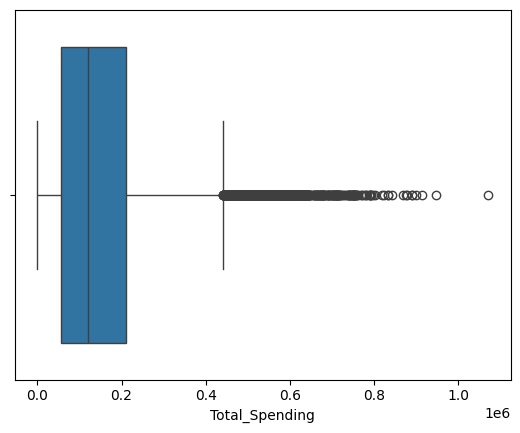

In [21]:
sns.boxplot(data=customer_df,x='Total_Spending')

In [22]:
customer_df.head(2)

,Customer_ID,Total_Spending,Total_Orders,Avg_Order_Value,Total_Quantity,Avg_Discount,Avg_Shipping_Cost,Recency
0,CUST00000001,40098.48,5,8019.696,5,0.0,17.352,169
1,CUST00000002,96487.46,10,9648.746,12,10.0,0.000,137


In [96]:
feature_col=customer_df.select_dtypes(include='number').columns
Q1 = customer_df[feature_col].quantile(0.25)
Q3 = customer_df[ feature_col].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_mask = (
    (customer_df[feature_col] < lower) |
    (customer_df[feature_col] > upper)
).any(axis=1)
customer_df = customer_df.loc[~outlier_mask].copy()

In [134]:
feature=customer_df.select_dtypes(include='number')
feature.skew()

Total_Spending      0.915333
Total_Orders        0.322247
Avg_Order_Value     0.795290
Total_Quantity      0.374938
Recency             0.981253
Cluster            -0.077757
Avg_Discount_log    0.025403
dtype: float64

<Axes: xlabel='Total_Spending', ylabel='Count'>

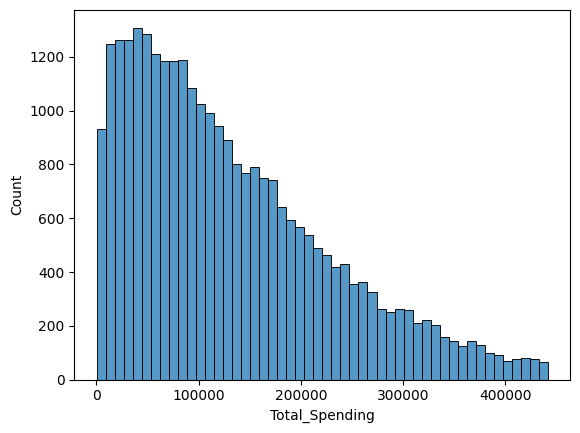

In [29]:
sns.histplot(data=customer_df,x='Total_Spending')

<Axes: xlabel='Avg_Discount'>

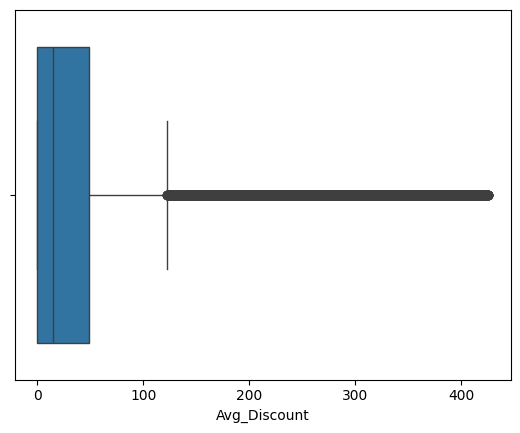

In [32]:
sns.boxplot(data=customer_df,x='Avg_Discount')

<Axes: xlabel='Avg_Discount_log', ylabel='Count'>

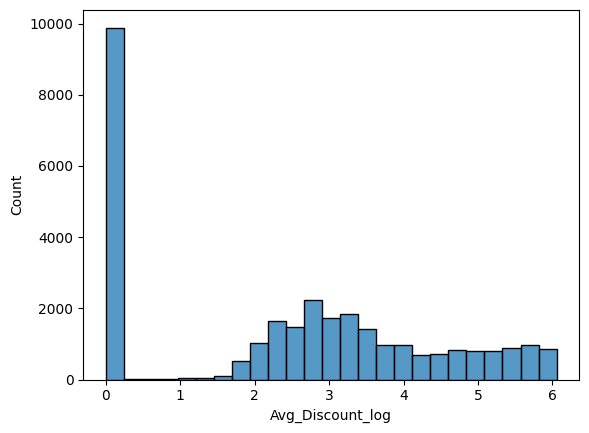

In [119]:
sns.histplot(
    data=customer_df,
    x='Avg_Discount_log'
)

In [118]:
customer_df['Avg_Discount_log']=np.log1p(customer_df['Avg_Discount'])

In [120]:
customer_df.drop(columns='Avg_Discount',inplace=True)

In [121]:
features = [
    'Total_Orders',
    'Avg_Order_Value',
    'Total_Quantity',
    'Recency',
    'Total_Spending',
    'Avg_Discount_log'
]

X = customer_df[features].values

In [122]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [123]:
X_scaled

array([[-0.54655967, -0.86846024, -0.88351655,  0.73584686, -0.89666157,
        -1.25117316],
       [ 1.60686797, -0.75298964,  1.3632232 ,  0.37196316, -0.31850682,
        -0.02757389],
       [-1.83861626,  1.16402813, -1.52544219,  0.19002132, -0.55534745,
        -1.25117316],
       ...,
       [ 1.60686797,  0.02816986,  0.72129756, -0.16249101,  0.81142587,
         0.16362488],
       [ 1.17618244,  0.16573484,  1.04226038, -0.78791612,  0.77859092,
         1.62766555],
       [-1.40793073, -0.51424782, -1.20447937, -0.52637471, -0.90740453,
         0.82581124]], shape=(30571, 6))

In [124]:
from sklearn.cluster import KMeans

In [125]:
# find the best K value

In [126]:
wcss=[]
for i in range (1,11):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=0)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

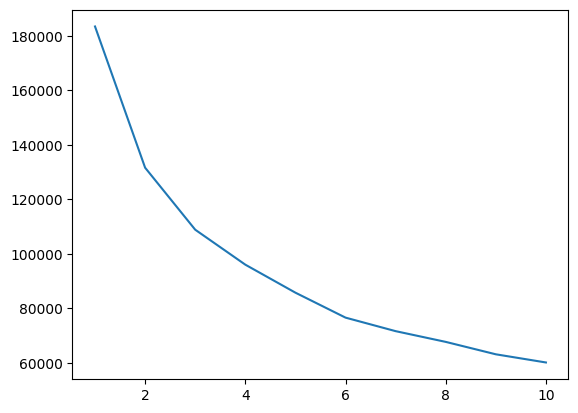

In [127]:
plt.plot(range(1,11),wcss)
plt.show()

# final model 

In [128]:
model=KMeans(n_clusters=5,init='k-means++',random_state=0)

In [129]:
from sklearn.decomposition import PCA

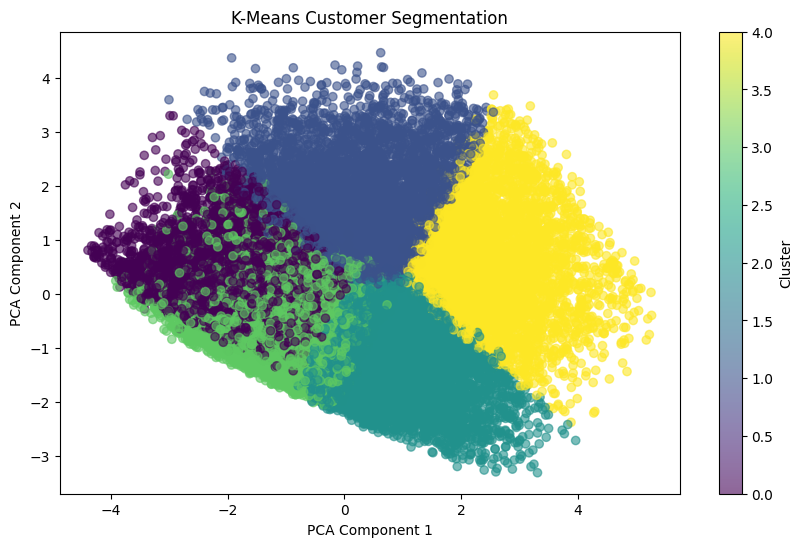

In [140]:
customer_df['Cluster'] = model.fit_predict(X_scaled)

# 5. PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 6. Plot
plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=customer_df['Cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Customer Segmentation')
plt.colorbar(label='Cluster')
plt.show()

In [141]:
# প্রতিটি ক্লাস্টারের মূল ফিচারগুলোর গড় মান বের করা
cluster_profile = customer_df.groupby('Cluster')[features].mean()

# আউটপুট সুন্দরভাবে দেখার জন্য
print(cluster_profile)

         Total_Orders  Avg_Order_Value  Total_Quantity     Recency  \
Cluster                                                              
0            4.301252     13234.835752        5.174644  131.127809   
1            5.319940     39327.650218        6.613030  119.765115   
2            8.268545     12797.721473       10.333290   64.900131   
3            4.922525     12283.865158        5.836545  131.389767   
4            8.944849     33570.412684       11.467027   70.904717   

         Total_Spending  Avg_Discount_log  
Cluster                                    
0          56344.002273          0.022755  
1         203299.977766          1.805636  
2         103777.109429          3.030445  
3          60112.650765          3.821481  
4         291957.036792          3.128282  


# Save Model

In [142]:
import pickle

In [143]:
model_pickle='model.pkl'

In [144]:
model_pickle='model.pkl'
with open(model_pickle,'wb') as f:
    pickle.dump(model,f)

In [145]:
print("Model saved successfully!")

Model saved successfully!


In [146]:
scaler_pickle = 'scaler.pkl'

with open(scaler_pickle, 'wb') as f:
    pickle.dump(scaler, f)